# Importing Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import make_regression

# Creating The Dataset

In [72]:
X, y = make_regression(n_samples=200,n_features=3,n_informative=3,noise=20,random_state=42)

In [73]:
print(f"X shape :{X.shape}, y shape :{y.shape}")

X shape :(200, 3), y shape :(200,)


In [74]:
# editing the dataset 
m = X.shape[0]
ones =np.ones((m,1))  
X = np.concatenate((ones, X), axis=1)

# Creating The model

In [75]:
# this function gives the expected values
def predict(X, w):
    return np.dot(X,w)

In [76]:
# this function finds the cost 
def cost_function(w , X , y):
    m = X.shape[0]
    j =  np.sum((predict(X , w) - y)**2)/(2*m)
    return j

In [77]:
# this function finds the gradient(derivative)
def gradient(w, X, y):
    m = X.shape[0]
    errors = predict(X, w) - y
    dw = (1/m) * np.dot(X.T , errors)
    return dw

In [78]:
#this function returns a list that contains the cost for every iteration and the best w
def gradient_descent(X,y,learning_rate,iterations):
    w = np.zeros(X.shape[1])
    cost = []
    for i in range(iterations):
        w = w -learning_rate * gradient(w, X, y)
        cost.append(cost_function(w, X, y))
    return cost,w

# Result

In [79]:

cost,w = gradient_descent(X,y,0.1,1000)
print(w)
print(f"final cost :{cost[-1]}")

[-0.73502087 71.2810152  20.76603986 73.28222391]
final cost :217.14465706808824


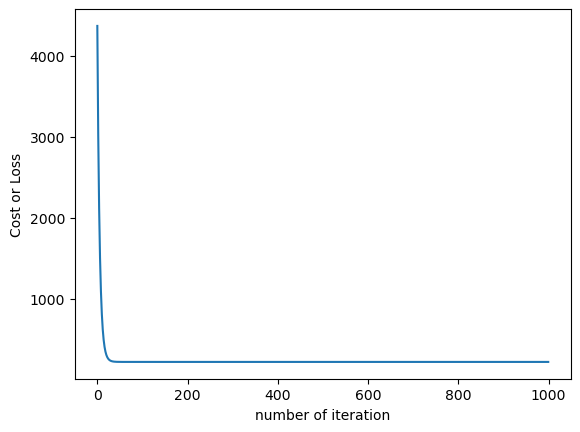

In [80]:
plt.plot(cost)
plt.xlabel("number of iteration")
plt.ylabel( "Cost or Loss")
plt.show()

# Sklearn VS Gradient descent

In [81]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
y_pred_sklearn = model.predict(X)


In [82]:
print(f"Sklearn weights : {model.coef_}")
print(f"My weights : {w[1:]}")   # w[1:] removes the bias


Sklearn weights : [ 0.         71.2810152  20.76603986 73.28222391]
My weights : [71.2810152  20.76603986 73.28222391]
